# Spectral decomposition closure 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import time

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance,
    compute_variance_groupby,
    compute_variance,
    put_fig_letter,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine


from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DT = 3
distance_to_coast_max = 20e3

In [3]:
band = ["", "LF", "diurnal", "inertial", "semidiurnal", "HF"]

# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess="spectral_decomp",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)


comb_list = [update_dict(base_dic, {"drifter_preprocess_param": b}) for b in band]


ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0 = ds0.where(ds0.depth == 0, drop=True)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)
ds0 = ds0.where(ds0.time_to_swot / pd.Timedelta("1h") < DT, drop=True)
# ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
ds0 = ds0.where(ds0.distance_to_coast > distance_to_coast_max, drop=True)
ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)
df0_ = ds0.to_dataframe().reset_index().set_index("row_number")


# DEPTH 15M
base_dic = update_dict(base_dic, {"wd_depth": "15"})

comb_list = [update_dict(base_dic, {"drifter_preprocess_param": b}) for b in band]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15 = ds15.where(ds15.depth == 15, drop=True)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)
ds15 = ds15.where(ds15.time_to_swot / pd.Timedelta("1h") < DT, drop=True)
# ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
ds15 = ds15.where(ds15.distance_to_coast > distance_to_coast_max, drop=True)

df15_ = ds15.to_dataframe().reset_index().set_index("row_number")

df0_["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df0_.latitude * np.pi / 180)
df15_["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df15_.latitude * np.pi / 180)

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__diurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__inertial__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__semidiurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__HF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__diurnal__swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__inertia

In [4]:
closure_vars = (
    ["ACC*", "COR*", "GGD*", "WD*", "S*", "sigma*"]
    + ["B*_" + v for v in ["acc", "cor", "ggd", "wd"]]
    + ["E*_" + v for v in ["acc", "cor", "ggd", "wd"]]
    + ["X*_acc_cor", "X*_acc_ggd", "X*_acc_wd", "X*_cor_ggd", "X*_cor_wd", "X*_ggd_wd"]
)
from diagnosis import assign_attrs

from scipy.stats import bootstrap

def compute_bootstrap_error(da, n_eff):
    x = da.values

    x = x[np.isfinite(x)]

    if len(x) < 3:
        return np.nan

    res = bootstrap(
        (x,),
        statistic=np.mean,
        method="percentile", #BCA too long
        n_resamples=1000,
        vectorized=True,
    )
    estimate = np.mean(x)

    n = len(x)
    
    factor = np.sqrt(n / n_eff)
    
    se = res.standard_error * factor
    
    low, high = res.confidence_interval.low, res.confidence_interval.high
    
    low = estimate + (low - estimate) * factor
    high = estimate + (high - estimate) * factor

    return high, low, se
    
def compute_bootstrap_error_percentage(dff, n_eff):
    x = dff["v"].values
    b = dff["denom"].values

    # Garder uniquement les observations valides dans les deux variables
    mask = np.isfinite(x) & np.isfinite(b)

    x = x[mask]
    b = b[mask]

    if len(x) < 3:
        return np.nan

    def percentage_mean(x, y, axis=-1):
        return np.mean(x, axis=axis) / np.mean(y, axis=axis)*100

    res = bootstrap(
        (x, b),
        statistic=percentage_mean,
        paired=True,
        n_resamples=1000,
        method="percentile", #BCA too long
        vectorized=True,
    )
    estimate = np.mean(x) / np.mean(b)*100

    n = len(x)
    
    factor = np.sqrt(n / n_eff)
    
    se = res.standard_error * factor
    
    low, high = res.confidence_interval.low, res.confidence_interval.high
    
    low = estimate + (low - estimate) * factor
    high = estimate + (high - estimate) * factor

    return high, low, se


def compute_mean_square(ds, dirname=("e", "n"), compute_error="no", vars_errors=None, Bpercentages=False, geopercentages=False):
    """Compute closure stats
    ds : dataset containing terms values for all row_numbers
    dirname : directions of the reconstruction
    """
    d0, d1 = dirname[0], dirname[1]

    closure_vars_ = closure_vars

    var = ["acc", "cor", "ggd", "wd", "sum"]
    VAR = ["ACC", "COR", "GGD", "WD", "S"]

    # if 'meancor'+dirname[0] in ds :
    #    print('ok')
    #    var += ['meancor', 'meanggd']
    #    VAR += ['meancor'.upper(), 'meanggd'.upper()]
    #    closure_vars_ = closure_vars +['MEANCOR*', 'MEANGGD*']

    dss = (
        (ds[[v + d1 for v in var] + [v + d0 for v in var]] ** 2)
        .rename({var[i] + d1: VAR[i] + d1 for i in range(len(var))})
        .rename({var[i] + d0: VAR[i] + d0 for i in range(len(var))})
    )
    dss["sigma" + d0] = (
        dss["ACC" + d0] + dss["COR" + d0] + dss["GGD" + d0] + dss["WD" + d0]
    )
    dss["sigma" + d1] = (
        dss["ACC" + d1] + dss["COR" + d1] + dss["GGD" + d1] + dss["WD" + d1]
    )

    nb_coloc = len(ds.row_number)

    # Balanced and error
    for direction in [d0, d1]:
        for v in ["acc", "cor", "ggd", "wd"]:
            dss["B" + direction + "_" + v] = -(
                (ds[v + direction] * ds["exc" + direction + "_" + v])
            )
            dss["E" + direction + "_" + v] = ds[v + direction] * ds["sum" + direction]

    # pairs contributions
    for v in [v for v in ds if "prod" in v]:
        dss[v.replace("prod", "X")] = -2 * ds[v]

    # Sum of both direction
    for v in closure_vars_:
        dss[v.replace("*", "")] = (
            dss[v.replace("*", dirname[0])] + dss[v.replace("*", dirname[1])]
        )
    # Balanced contribution for all
    dss['B'] = (dss['B_'+var[0]] + dss['B_'+var[1]] + dss['B_'+var[2]]+dss['B_'+var[3]]).sel(id_comb='all')
    
    # Mean
    dsm = dss.mean("row_number")

    #percentage 
    for v in [v for v in dss if "X_" in v]:
        dsm[v+'__B'] = dsm[v]/dsm['B']*100
        dsm[v+'__geo'] = dsm[v]/dsm['X_cor_ggd']*100

    # STATISTICAL ERRORS
    effective_degree = len(
            ds.isel(id_comb=0)
            .to_dataframe()
            .groupby(["drifter_id", "cycle_number", "pass_number"], observed=False)
            .count()
        )
    print(effective_degree)

    # central limit
    if compute_error == "centrallimit":
        # effective freedom degree
        # dsme = (2*dss.std('row_number')/np.sqrt(nb_coloc)).rename({v:'er__'+v for v in list(dss.keys())})
        dsme = (2 * dss.std("row_number") / np.sqrt(effective_degree))
        dsm = xr.concat([dsm, dsme], dim=pd.Index(['estimation', 'stde'], name='value'))

    # bootstrap
    if compute_error == "bootstrap":
        if vars_errors == None:
            vars_errors = (
                [v.replace("*", "") for v in closure_vars]
                #+[v.replace("*", dirname[0]) for v in closure_vars]
                #+ [v.replace("*", dirname[1]) for v in closure_vars]
                )
            #print(vars_errors)

        D = []
        for id_ in dss.id_comb:
            dsml = xr.Dataset()
            dsml["id_comb"] = id_
            dsml = dsml.set_coords("id_comb").expand_dims("id_comb")
            dsmh=dsml.copy()
            dsmstd = dsml.copy()
            for v in vars_errors:
                high, low, std = compute_bootstrap_error(dss.sel(id_comb=id_)[v], effective_degree)
                dsml[v] = ("id_comb",[low])
                dsmh[v] = ("id_comb",[high])
                dsmstd[v] = ("id_comb",[std])
                
            if Bpercentages :
                for v in [v for v in dss if "X_" in v]:
                    high, low, std = compute_bootstrap_error_percentage(dss.sel(id_comb=id_)[[v, 'B']].rename({v:'v','B':'denom'}), effective_degree)
                    dsml[v+'__B'] = ("id_comb",[low])
                    dsmh[v+'__B'] = ("id_comb",[high])
                    dsmstd[v+'__B'] = ("id_comb",[std])
            if geopercentages :
                for v in [v for v in dss if ("X_" in v) & ("cor_ggd" not in v)]:
                    high, low, std = compute_bootstrap_error_percentage(dss.sel(id_comb=id_)[[v, 'X_cor_ggd']].rename({v:'v','X_cor_ggd':'denom'}), effective_degree)
                    dsml[v+'__geo'] = ("id_comb",[low])
                    dsmh[v+'__geo'] = ("id_comb",[high])
                    dsmstd[v+'__geo'] = ("id_comb",[std])
            D.append(xr.concat([dsml, dsmh, dsmstd], dim=pd.Index(['low', 'high', 'stde'], name='value')))
            print(id_.values)
        dsme = xr.concat(D, dim="id_comb")
        dsm['value'] = 'estimation'
        dsm = xr.concat([dsm.set_coords("value").expand_dims(dim="value"), dsme], dim='value')

    # ATTRS
    dsm.attrs["error_method"] = compute_error
    dsm = assign_attrs(dsm, list(dirname) + [""])
    return dsm


def compute_variance(ds_, dirname=("e", "n"), compute_error="no", vars_errors=None, Bpercentages=False, geopercentages=False):
    """Compute closure stats
    ds : dataset containing terms values for all row_numbers
    dirname : directions of the reconstruction
    """

    var = ["acc", "cor", "ggd", "wd"]

    ds = ds_.copy()
    # remove mean
    for dir_ in dirname:
        for v in var:
            ds[v + dir_] = ds[v + dir_] - ds[v + dir_].mean("row_number")

        # sum
        ds["sum" + dir_] = sum([ds[v + dir_] for v in var])

        # simple var + sum- one term
        for v in var:
            ds["exc" + dir_ + "_" + v] = ds["sum" + dir_] - ds[v + dir_]

        # 2 by 2 product
        import itertools

        l = {
            "acc": "acc" + dir_,
            "cor": "cor" + dir_,
            "ggd": "ggd" + dir_,
            "wd": "wd" + dir_,
        }
        couple = list(itertools.combinations(list(l.keys()), 2))
        for c in couple:
            ds["prod" + dir_ + "_" + "_".join(c)] = ds[c[0] + dir_] * ds[c[1] + dir_]

    # MS = var as mean are null
    dsm = compute_mean_square(ds, dirname, compute_error, vars_errors, Bpercentages, geopercentages)
    return dsm

# Compute with bootstrap, long so we store it :

In [5]:
ds0["id_comb"] = ["all"] + band[1:]
DS0 = ds0.where(ds0.depth == 0, drop=True)
DS0 = DS0.where(DS0.time_to_swot / pd.Timedelta("1h") < DT).dropna("row_number")
DS0 = DS0.where(DS0.distance_to_coast > distance_to_coast_max, drop=True)
DS0 = DS0.where((abs(DS0.sel(id_comb="HF").acce) < 5e-5) & (abs(DS0.sel(id_comb="HF").accn) < 5e-5))

                
ds15["id_comb"] = ["all"] + band[1:]

DS15 = ds15.where(ds15.depth == 15, drop=True)
DS15 = DS15.where(DS15.time_to_swot / pd.Timedelta("1h") < DT).dropna("row_number")
DS15 = DS15.where(DS15.distance_to_coast > distance_to_coast_max, drop=True)
DS15 = DS15.where(
    (abs(DS15.sel(id_comb="HF").acce) < 5e-5)
    & (abs(DS15.sel(id_comb="HF").accn) < 5e-5)
)  # outliers

f0 = (2 * 2 * np.pi / 86164.1 * np.sin(DS0.latitude * np.pi / 180)).mean()
f15 = (2 * 2 * np.pi / 86164.1 * np.sin(DS15.latitude * np.pi / 180)).mean()

In [6]:
ds0_ = (compute_variance(DS0, compute_error="bootstrap", Bpercentages=True))
ds0_.to_netcdf('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/closure_spectral_decomp_bootstrap_z0.nc')

1171
all
LF
diurnal
inertial
semidiurnal
HF


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [7]:

ds15_ = compute_variance(DS15, compute_error="bootstrap", Bpercentages=True)
ds15_.to_netcdf('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/closure_spectral_decomp_bootstrap_z15.nc')

944
all
LF
diurnal
inertial
semidiurnal
HF


In [37]:
DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < DT).dropna("row_number")
DS = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)

DS = DS.where(
    (abs(DS.sel(id_comb="HF").acce) < 5e-5) & (abs(DS.sel(id_comb="HF").accn) < 5e-5)
)

ds_ = compute_variance(DS, compute_error="bootstrap", Bpercentages=True)
ds_.to_netcdf('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/closure_spectral_decomp_bootstrap_zall.nc')

all
LF
diurnal
inertial
semidiurnal
HF


# Load stored data

In [8]:
ds0= xr.open_dataset('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/closure_spectral_decomp_bootstrap_z0.nc').sel(value=['low','estimation','high','stde']).transpose("id_comb", "value")
ds15= xr.open_dataset('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/closure_spectral_decomp_bootstrap_z15.nc').sel(value=['low','estimation','high','stde']).transpose("id_comb", "value")
#ds= xr.open_dataset('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/closure_spectral_decomp_bootstrap_zall.nc').sel(value=['low','estimation','high','stde']).transpose("id_comb", "value")

for v in [v for v in ds0 if '__' not in v]:
    #ds[v]=ds[v]/U2
    ds0[v]=ds0[v]/U2
    ds15[v]=ds15[v]/U2
f0 = 9.40144567e-05
f15 = 9.51646216e-05

# Compute 95% errors 
ds0 = xr.concat([ds0, (ds0.sel(value="stde")*1.96).assign_coords(value="er95")],dim="value")
ds15 = xr.concat([ds15, (ds15.sel(value="stde")*1.96).assign_coords(value="er95")],dim="value")

____________
# Fig and results for GRL2 - Paired Contribution

In [9]:
X_ = [v for v in ds0 if ('X_' in v)&('__' not in v)]
Bper = [v for v in ds0 if '__B' in v]

In [10]:
np.round((ds0[X_]), 3).to_dataframe()

X_acc_cor  X_acc_ggd  X_acc_wd  X_cor_ggd  X_cor_wd  \
id_comb     value                                                             
all         low             6.230     -0.416    -0.296      3.455     1.240   
            estimation      6.890     -0.139    -0.148      3.963     1.623   
            high            7.527      0.164    -0.001      4.454     1.966   
            stde            0.330      0.145     0.075      0.261     0.181   
            er95            0.648      0.283     0.146      0.512     0.356   
LF          low             0.347     -0.258    -0.070      3.478     1.277   
            estimation      0.441     -0.194    -0.032      3.867     1.552   
            high            0.531     -0.128     0.002      4.247     1.816   
            stde            0.048      0.033     0.018      0.196     0.134   
            er95            0.094      0.066     0.036      0.385     0.263   
diurnal     low             0.438     -0.136    -0.099     -0.048     0.165   
            estimation      0.469     -0.077    -0.092      0.035     0.180   
            high            0.499     -0.022    -0.085      0.115     0.195   
            stde            0.015      0.030     0.004      0.041     0.008   
            er95            0.030      0.058     0.007      0.080     0.015   
inertial    low             4.286     -0.128    -0.152     -0.132     0.136   
            estimation      4.630      0.075    -0.123      0.065     0.167   
            high            4.966      0.276    -0.098      0.258     0.194   
            stde            0.179      0.104     0.014      0.102     0.015   
            er95            0.352      0.204     0.027      0.199     0.029   
semidiurnal low             0.084     -0.059    -0.003     -0.019     0.002   
            estimation      0.091     -0.019    -0.001      0.008     0.002   
            high            0.099      0.025    -0.000      0.035     0.003   
            stde            0.004      0.022     0.001      0.014     0.000   
            er95            0.007      0.043     0.001      0.027     0.001   
HF          low             0.343     -0.078    -0.016     -0.072     0.005   
            estimation      0.385      0.059    -0.005     -0.013     0.010   
            high            0.426      0.192     0.007      0.041     0.015   
            stde            0.021      0.071     0.006      0.030     0.003   
            er95            0.041      0.138     0.011      0.058     0.005   

                        X_ggd_wd  
id_comb     value                 
all         low           -0.075  
            estimation     0.086  
            high           0.244  
            stde           0.081  
            er95           0.160  
LF          low           -0.085  
            estimation     0.059  
            high           0.210  
            stde           0.075  
            er95           0.147  
diurnal     low            0.000  
            estimation     0.026  
            high           0.050  
            stde           0.012  
            er95           0.024  
inertial    low           -0.037  
            estimation    -0.009  
            high           0.015  
            stde           0.013  
            er95           0.026  
semidiurnal low           -0.003  
            estimation     0.003  
            high           0.010  
            stde           0.003  
            er95           0.006  
HF          low           -0.021  
            estimation    -0.003  
            high           0.017  
            stde           0.010  
            er95           0.019

In [11]:
np.round((ds15[X_]), 3).to_dataframe()

X_acc_cor  X_acc_ggd  X_acc_wd  X_cor_ggd  X_cor_wd  \
id_comb     value                                                             
all         low             3.510     -0.449    -0.096      3.823     0.184   
            estimation      3.998     -0.216    -0.035      4.258     0.295   
            high            4.424      0.019     0.025      4.693     0.415   
            stde            0.239      0.121     0.032      0.223     0.059   
            er95            0.469      0.237     0.063      0.436     0.115   
LF          low             0.282     -0.226    -0.023      3.726     0.206   
            estimation      0.356     -0.167    -0.013      4.113     0.275   
            high            0.428     -0.103    -0.001      4.498     0.341   
            stde            0.038      0.032     0.006      0.198     0.034   
            er95            0.074      0.062     0.011      0.388     0.067   
diurnal     low             0.180     -0.171    -0.029      0.090     0.034   
            estimation      0.201     -0.127    -0.026      0.148     0.038   
            high            0.221     -0.083    -0.023      0.208     0.042   
            stde            0.010      0.023     0.001      0.029     0.002   
            er95            0.021      0.045     0.003      0.058     0.004   
inertial    low             2.626     -0.098    -0.032     -0.211     0.026   
            estimation      2.855      0.073    -0.025     -0.038     0.034   
            high            3.080      0.261    -0.017      0.135     0.042   
            stde            0.120      0.093     0.004      0.086     0.004   
            er95            0.235      0.182     0.007      0.168     0.008   
semidiurnal low             0.037     -0.051     0.000     -0.008    -0.000   
            estimation      0.041     -0.018     0.000      0.013     0.000   
            high            0.046      0.015     0.001      0.034     0.000   
            stde            0.002      0.016     0.000      0.011     0.000   
            er95            0.004      0.032     0.000      0.021     0.000   
HF          low             0.191     -0.097     0.001     -0.046    -0.002   
            estimation      0.216      0.022     0.004      0.002    -0.000   
            high            0.240      0.138     0.007      0.053     0.001   
            stde            0.012      0.060     0.002      0.025     0.001   
            er95            0.024      0.117     0.003      0.049     0.001   

                        X_ggd_wd  
id_comb     value                 
all         low           -0.004  
            estimation     0.042  
            high           0.090  
            stde           0.024  
            er95           0.047  
LF          low            0.017  
            estimation     0.067  
            high           0.118  
            stde           0.026  
            er95           0.051  
diurnal     low           -0.032  
            estimation    -0.024  
            high          -0.015  
            stde           0.005  
            er95           0.009  
inertial    low           -0.011  
            estimation    -0.002  
            high           0.007  
            stde           0.004  
            er95           0.009  
semidiurnal low            0.001  
            estimation     0.003  
            high           0.006  
            stde           0.001  
            er95           0.002  
HF          low           -0.006  
            estimation    -0.000  
            high           0.006  
            stde           0.003  
            er95           0.006

In [12]:
np.round((ds0[Bper]), 2).to_dataframe()

X_acc_cor__B  X_acc_ggd__B  X_acc_wd__B  X_cor_ggd__B  \
id_comb     value                                                               
all         low                52.72         -3.61        -2.39         29.15   
            estimation         56.13         -1.13        -1.21         32.29   
            high               59.59          1.19        -0.08         35.70   
            stde                1.77          1.23         0.58          1.69   
            er95                3.46          2.40         1.13          3.31   
LF          low                 2.91         -2.11        -0.55         28.62   
            estimation          3.59         -1.58        -0.26         31.51   
            high                4.29         -1.06         0.01         34.23   
            stde                0.36          0.27         0.14          1.46   
            er95                0.70          0.53         0.28          2.86   
diurnal     low                 3.49         -1.11        -0.82         -0.38   
            estimation          3.82         -0.63        -0.75          0.29   
            high                4.13         -0.15        -0.68          0.97   
            stde                0.16          0.25         0.04          0.34   
            er95                0.31          0.48         0.07          0.67   
inertial    low                34.84         -1.11        -1.22         -1.10   
            estimation         37.72          0.61        -1.00          0.53   
            high               40.45          2.29        -0.79          2.12   
            stde                1.46          0.86         0.11          0.83   
            er95                2.85          1.70         0.22          1.63   
semidiurnal low                 0.67         -0.50        -0.02         -0.15   
            estimation          0.74         -0.15        -0.01          0.07   
            high                0.81          0.19         0.00          0.30   
            stde                0.04          0.18         0.01          0.12   
            er95                0.07          0.35         0.01          0.23   
HF          low                 2.77         -0.70        -0.13         -0.59   
            estimation          3.13          0.48        -0.04         -0.11   
            high                3.50          1.65         0.06          0.36   
            stde                0.19          0.61         0.05          0.25   
            er95                0.37          1.19         0.09          0.49   

                        X_cor_wd__B  X_ggd_wd__B  
id_comb     value                                 
all         low               10.70        -0.64  
            estimation        13.22         0.70  
            high              15.84         1.90  
            stde               1.32         0.67  
            er95               2.59         1.32  
LF          low               10.82        -0.79  
            estimation        12.64         0.48  
            high              14.59         1.58  
            stde               0.99         0.61  
            er95               1.94         1.19  
diurnal     low                1.33         0.02  
            estimation         1.47         0.21  
            high               1.63         0.41  
            stde               0.07         0.10  
            er95               0.15         0.20  
inertial    low                1.14        -0.31  
            estimation         1.36        -0.08  
            high               1.59         0.13  
            stde               0.11         0.11  
            er95               0.22         0.21  
semidiurnal low                0.01        -0.02  
            estimation         0.02         0.03  
            high               0.03         0.08  
            stde               0.00         0.03  
            er95               0.01         0.05  
HF          low                0.04        -0.17  
   

In [13]:
np.round((ds15[Bper]), 2).to_dataframe()

X_acc_cor__B  X_acc_ggd__B  X_acc_wd__B  X_cor_ggd__B  \
id_comb     value                                                               
all         low                44.59         -5.27        -1.17         47.59   
            estimation         47.93         -2.59        -0.42         51.04   
            high               51.83          0.13         0.33         54.56   
            stde                1.89          1.41         0.39          1.83   
            er95                3.71          2.76         0.76          3.59   
LF          low                 3.34         -2.66        -0.28         45.89   
            estimation          4.26         -2.00        -0.15         49.30   
            high                5.17         -1.30        -0.02         52.90   
            stde                0.46          0.36         0.07          1.81   
            er95                0.89          0.70         0.13          3.54   
diurnal     low                 2.13         -2.03        -0.35          1.13   
            estimation          2.40         -1.52        -0.31          1.78   
            high                2.65         -1.01        -0.27          2.47   
            stde                0.13          0.27         0.02          0.35   
            er95                0.26          0.53         0.04          0.69   
inertial    low                31.60         -1.27        -0.38         -2.66   
            estimation         34.22          0.88        -0.30         -0.46   
            high               36.95          3.02        -0.21          1.65   
            stde                1.39          1.11         0.05          1.12   
            er95                2.73          2.17         0.09          2.19   
semidiurnal low                 0.43         -0.57        -0.00         -0.11   
            estimation          0.50         -0.22         0.00          0.15   
            high                0.56          0.16         0.01          0.42   
            stde                0.03          0.19         0.00          0.13   
            er95                0.06          0.38         0.00          0.25   
HF          low                 2.28         -1.04         0.01         -0.54   
            estimation          2.59          0.26         0.05          0.03   
            high                2.95          1.62         0.09          0.69   
            stde                0.17          0.68         0.02          0.31   
            er95                0.33          1.34         0.04          0.60   

                        X_cor_wd__B  X_ggd_wd__B  
id_comb     value                                 
all         low                2.22        -0.04  
            estimation         3.53         0.51  
            high               4.90         1.10  
            stde               0.68         0.29  
            er95               1.33         0.56  
LF          low                2.58         0.24  
            estimation         3.30         0.80  
            high               4.10         1.35  
            stde               0.41         0.28  
            er95               0.80         0.56  
diurnal     low                0.40        -0.40  
            estimation         0.45        -0.29  
            high               0.51        -0.18  
            stde               0.03         0.06  
            er95               0.05         0.11  
inertial    low                0.31        -0.13  
            estimation         0.41        -0.03  
            high               0.50         0.08  
            stde               0.05         0.05  
            er95               0.09         0.10  
semidiurnal low               -0.00         0.01  
            estimation         0.00         0.04  
            high               0.00         0.07  
            stde               0.00         0.01  
            er95               0.00         0.03  
HF          low               -0.02        -0.08  
   

In [26]:
np.round(ds0['E_cor'].sel(id_comb='LF'), 2).to_dataframe(), np.round(ds15['E_cor'].sel(id_comb='LF'), 2).to_dataframe()

(           id_comb  E_cor
 value                    
 low             LF   0.78
 estimation      LF   0.93
 high            LF   1.08
 stde            LF   0.08
 er95            LF   0.15,
            id_comb  E_cor
 value                    
 low             LF   0.43
 estimation      LF   0.57
 high            LF   0.69
 stde            LF   0.07
 er95            LF   0.13)

In [25]:
np.round(ds0['E_acc'].sel(id_comb='HF'), 2).to_dataframe(), np.round(ds15['E_acc'].sel(id_comb='HF'), 2).to_dataframe()

(           id_comb  E_acc
 value                    
 low             HF   0.62
 estimation      HF   0.71
 high            HF   0.82
 stde            HF   0.05
 er95            HF   0.10,
            id_comb  E_acc
 value                    
 low             HF   0.31
 estimation      HF   0.38
 high            HF   0.46
 stde            HF   0.04
 er95            HF   0.07)

In [16]:
ds0['id_comb']= ["Full-spectrum", "LF", "Diurnal", "Inertial", "Semidiurnal", "HF"]
df0 = ds0[X_+['E_cor', 'E_acc', 'B_acc', 'B_ggd', 'B_wd']+Bper].to_dataframe()

ds15['id_comb']= ["Full-spectrum", "LF", "Diurnal", "Inertial", "Semidiurnal", "HF"]
df15 = ds15[X_+['E_cor', 'E_acc', 'B_acc', 'B_ggd', 'B_wd']+Bper].to_dataframe()

In [19]:
def plot__(df, axs, i0):
    i = i0

    for b in ["Full-spectrum", "LF", "Inertial", "HF"]:
        df_ = df.loc[b]
        ax = axs[i]

        def axbar(ax, i, df__, color, hatch_color, **kwargs):
            e = df__.loc["estimation"]
            err_h = df__.loc["high"] - e
            err_l = e - df__.loc["low"]

            ax.bar(
                i,
                e,
                color=color,
                edgecolor=hatch_color,
                hatch="/",
                yerr=[[err_l], [err_h]],
                capsize=2,
                **kwargs
            )
            # Valeur au-dessus de la barre 
            bottom = kwargs.get("bottom", 0)
            ax.text( i, e + err_h+bottom + 0.02 * ax.get_ylim()[1], f"{e:.1f}", ha="center", va="bottom", fontsize=9, )
        
        axbar(
            ax, 0,
            df_["X_acc_cor"],
            color=c0["acc"],
            hatch_color=c0["cor"]
        )

        axbar(
            ax, 1,
            df_["X_acc_ggd"],
            color=c0["acc"],
            hatch_color=c0["ggd"]
        )

        axbar(
            ax, 2,
            df_["X_cor_ggd"],
            color=c0["ggd"],
            hatch_color=c0["cor"]
        )

        axbar(
            ax, 3,
            df_["X_cor_wd"],
            color=c0["wd"],
            hatch_color=c0["cor"]
        )
        n=0
        for Bper_ in ["X_acc_cor", "X_acc_ggd", "X_cor_ggd", "X_cor_wd"]:
            per = df_.loc["estimation"][Bper_+'__B']
            ax.text(n, -0.3, f"{round(per)} %", ha="center", va="top", fontsize=9, )
            n+=1

        if i < 4:
            ax.set_title(b)

        L = ["c", "d", "e", "f", "g", "h", "i", "j"]
        put_fig_letter(fig, axs[i], L[i])

        i += 1

    
    # Resolution mismatch errors
    plt.rcParams["hatch.color"] = "lightgrey"
    axbar(axs[i0 + 1], 2.5, df.loc["LF"]['E_cor']*2, color="lightgrey",hatch_color='lightgrey', bottom=6,width=0.8,)
    axbar(axs[i0 + 3], 1, df.loc["HF"]['E_acc']*2, color="lightgrey", hatch_color='lightgrey', bottom=3, width=0.8,)

import matplotlib.transforms as mtransforms
def put_fig_letter(fig, ax, letter):
    trans = mtransforms.ScaledTranslation(5/ 72, -5 / 72, fig.dpi_scale_trans)
    ax.text(
        0.0,
        1.0,
        letter + ")",
        transform=ax.transAxes + trans,
        fontsize="medium",
        verticalalignment="top",
        fontfamily="serif",
        bbox=dict(facecolor="0.7", edgecolor="none", pad=3.0),
        zorder=30,
    )

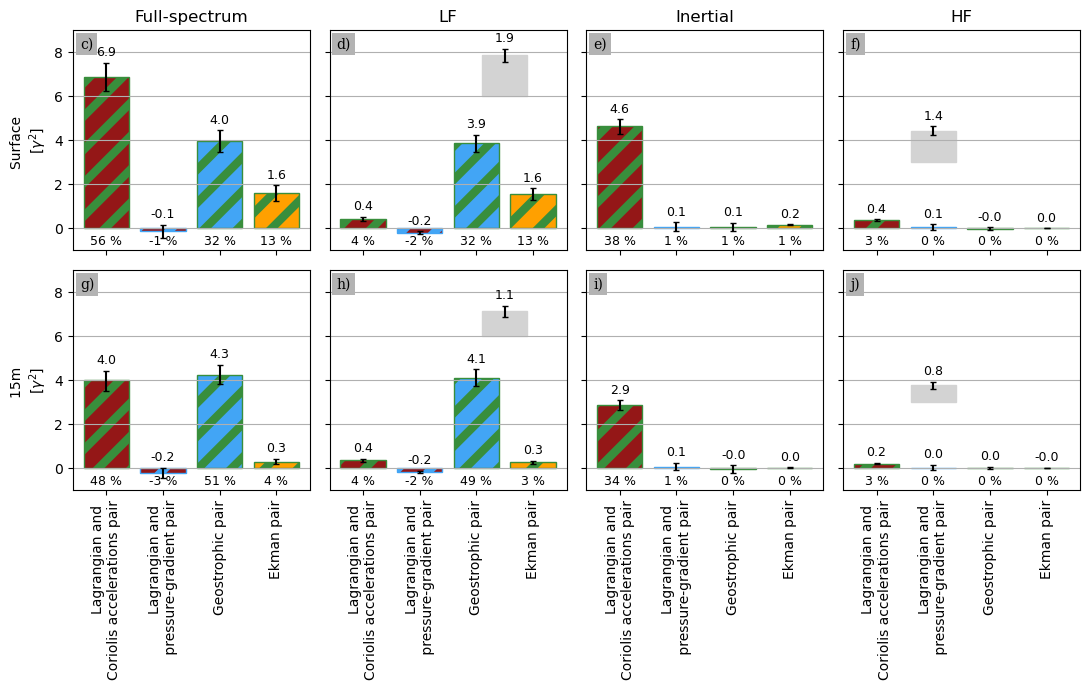

In [20]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(2, 4, figsize=(11, 7), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
plot__(df0, axs, 0)
plot__(df15, axs, 4)
i=0
for ax in axs:
    ax.grid(axis="y")
    ax.set_ylim(-1, 9)
    ax.set_xticks(
        [0, 1, 2, 3],
        [
            "Lagrangian and \nCoriolis accelerations pair",
            "Lagrangian and \n pressure-gradient pair",
            "Geostrophic pair",
            "Ekman pair",
        ],
        rotation=90,
        ha="right",
        va="center",
        rotation_mode="anchor",
    )
    i+=1
axs[0].set_ylabel("Surface \n" + r"[$\gamma^2$]")
axs[4].set_ylabel("15m \n" + r"[$\gamma^2$]")
fig.tight_layout()

### Equivalent velocities STD

In [21]:
def velocities(dm, f, v):
    e = np.sqrt(dm.loc['estimation'][v] / (f**2) * U2 / 2)
    er = e * 1 / 2 * (dm.loc['er95'][v] / dm.loc['estimation'][v])
    print(
        "Velocities "
        + v
        + f" :    {np.round(e*100, 1)}\pm {np.round(er*100, 1)} cm.s-1"
    )

In [22]:
velocities(df0.loc["LF"], f0, "B_wd"), velocities(
    df15.loc["LF"], f15, "B_wd"
)

Velocities B_wd :    6.6\pm 0.5 cm.s-1
Velocities B_wd :    3.0\pm 0.3 cm.s-1


(None, None)

In [23]:
velocities(df0.loc["LF"], f0, "B_ggd"), velocities(
    df15.loc["LF"], f15, "B_ggd"
)

Velocities B_ggd :    10.1\pm 0.4 cm.s-1
Velocities B_ggd :    10.3\pm 0.5 cm.s-1


(None, None)

In [24]:
velocities(df0.loc["Inertial"], f0, "B_acc"), velocities(
    df15.loc["Inertial"], f15, "B_acc"
)

Velocities B_acc :    11.2\pm 0.5 cm.s-1
Velocities B_acc :    8.8\pm 0.4 cm.s-1


(None, None)

/dev/shm/pbs.4461054.datarmor0/ipykernel_49223/2404017841.py:64: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[0].annotate(
/dev/shm/pbs.4461054.datarmor0/ipykernel_49223/2404017841.py:74: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[4].annotate(


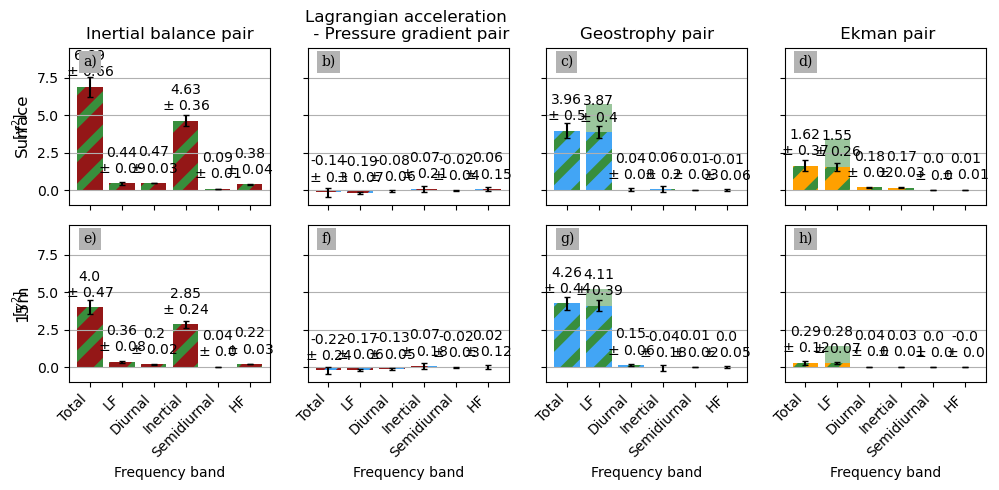

In [19]:
def print_labels(df, X, ax):
    for i in range(0, 6):
        # SX = df.iloc[i][[v for v in df.columns if ('X_' in v)&('er__' not in v)]].sum()
        # SX = df.loc['Full-spectrum'].X_cor_ggd
        # erSX = df.loc['Full-spectrum'].er__X_cor_ggd

        label = (
            rf"{np.round(df[X].iloc[i], 2)}"
            + "\n"
            + rf"$\pm$ {np.round(df['er__' + X].iloc[i], 2)}"
        )
        # if i in [1,2, 3, 4] :
        #    label = label + '\n' + rf"{int(df[X].iloc[i]/SX*100)} $\pm$ {int(df[X].iloc[i]/SX*100*((df['er__'+X]/df[X]).iloc[i] + erSX/SX))}%"
        ax.text(
            i,
            df[X].iloc[i] + 0.5,
            label,
            horizontalalignment="center",
            verticalalignment="bottom",
            rotation=0,
        )


plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(2, 4, figsize=(10, 5), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

kwargs = dict(hatch="/", width=0.8, capsize=2)


def plot(df_, axs, init):
    ax = axs[init + 0]
    plt.rcParams["hatch.color"] = c0["cor"]
    df_.x_cor.plot.bar(color=c0["acc"], ax=ax, yerr=df_["er__x_cor"], **kwargs)
    print_labels(df_, "x_cor", ax)

    ax = axs[init + 1]
    plt.rcParams["hatch.color"] = c0["ggd"]
    df_.x_ggd.plot.bar(color=c0["acc"], ax=ax, yerr=df_["er__x_ggd"], **kwargs)
    print_labels(df_, "x_ggd", ax)

    ax = axs[init + 2]
    plt.rcParams["hatch.color"] = c0["cor"]
    df_.X_cor_ggd.plot.bar(color=c0["ggd"], ax=ax, yerr=df_["er__X_cor_ggd"], **kwargs)
    print_labels(df_, "X_cor_ggd", ax)

    ax = axs[init + 3]
    plt.rcParams["hatch.color"] = c0["cor"]
    df_.X_cor_wd.plot.bar(color=c0["wd"], ax=ax, yerr=df_["er__X_cor_wd"], **kwargs)
    print_labels(df_, "X_cor_wd", ax)


plot(df0, axs, 0)
plot(df15, axs, 4)

axs[0].set_title("Inertial balance pair")
axs[1].set_title("Lagrangian acceleration \n - Pressure gradient pair")
axs[2].set_title("Geostrophy pair")
axs[3].set_title(" Ekman pair")

pad = 0
axs[0].annotate(
    "Surface",
    xy=(-0.23, 0.5),
    xycoords="axes fraction",
    textcoords="offset points",
    size="large",
    ha="center",
    va="center",
    rotation=90,
)
axs[4].annotate(
    "15m",
    xy=(-0.23, 0.5),
    xycoords="axes fraction",
    textcoords="offset points",
    size="large",
    ha="center",
    va="center",
    rotation=90,
)

l = ["a", "b", "c", "d", "e", "f", "g", "h"]
for i in range(len(axs)):
    put_fig_letter(fig, axs[i], l[i])

for ax in axs:
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_xticks(
        [0, 1, 2, 3, 4, 5],
        ["Full-spectrum", "LF", "Diurnal", "Inertial", "Semidiurnal", "HF"],
        rotation=45,
        ha="right",
    )

axs[0].set_ylim(-1, 9.5)

#### Add Possible paired contributions from resolution mismatch ####

axs[2].bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_ggd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
axs[3].bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_wd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
axs[6].bar(
    1,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_ggd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
axs[7].bar(
    1,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_wd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
# (df0.E_cor.loc['LF']*2).plot.bar(x=1, ax=axs[3], bottom = df0.X_cor_ggd.loc['LF'], color = 'lightgrey')

fig.tight_layout()

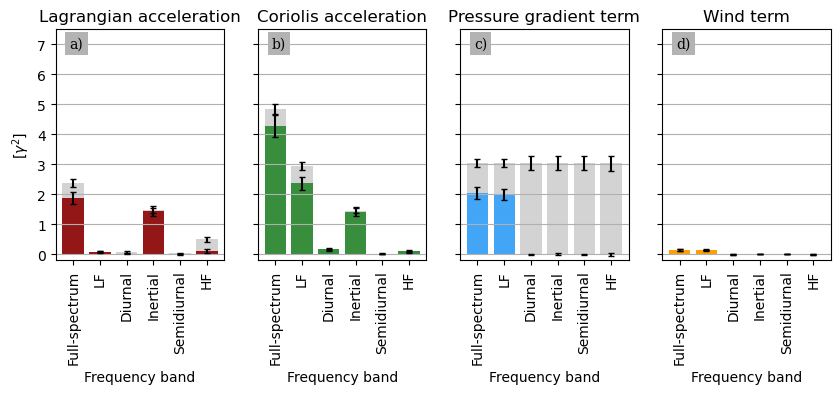

In [10]:
vars = ["acc", "cor", "ggd", "wd"]
title = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggd": "Pressure gradient term",
    "wd": "Wind term",
}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(1, 4, figsize=(10, 3), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
for j in range(len(vars)):
    ax = axs[j]
    df15["E_" + vars[j]].plot.bar(
        ax=ax,
        color="lightgrey",
        bottom=df15["B_" + vars[j]],
        yerr=df15["er__E_" + vars[j]],
        **kwargs
    )
    df15["B_" + vars[j]].plot.bar(
        ax=ax, color=c0[vars[j]], yerr=df15["er__B_" + vars[j]], **kwargs
    )
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_title(title[vars[j]])
    ax.set_ylim(-0.2, 7.5)

i = 0
for l in ["a", "b", "c", "d"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

____________
# Fig and results for GRL1 - Balanced VS residuals contributions

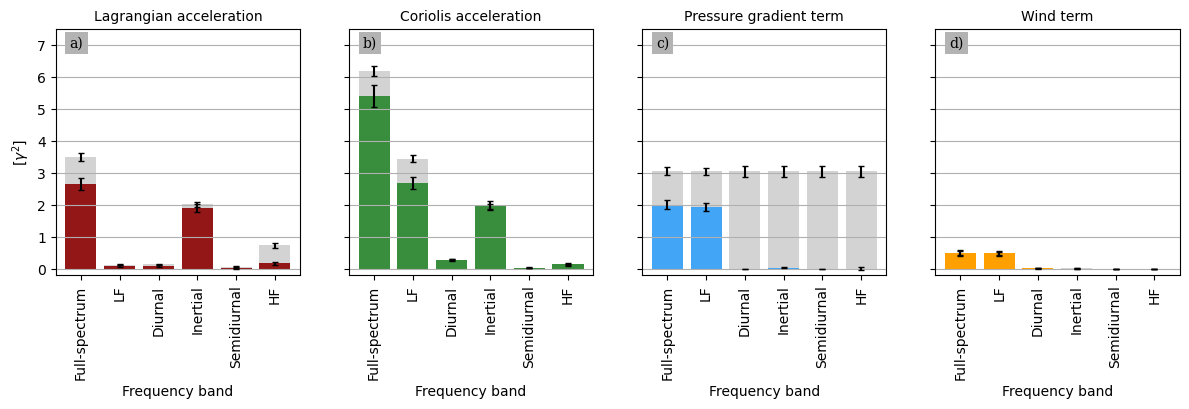

In [8]:
vars = ["acc", "cor", "ggd", "wd"]
title = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggd": "Pressure gradient term",
    "wd": "Wind term",
}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(
    1, 4, figsize=(14.5, 3.2), frameon=False, sharex=True, sharey=True
)
axs = axs.flatten()
for j in range(len(vars)):
    ax = axs[j]
    df["E_" + vars[j]].plot.bar(
        ax=ax,
        color="lightgrey",
        bottom=df["B_" + vars[j]],
        yerr=df["er__E_" + vars[j]],
        **kwargs
    )
    df["B_" + vars[j]].plot.bar(
        ax=ax, color=c0[vars[j]], yerr=df["er__B_" + vars[j]], **kwargs
    )
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_title(title[vars[j]], fontsize=10)
    ax.set_ylim(-0.2, 7.5)

i = 0
for l in ["a", "b", "c", "d"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

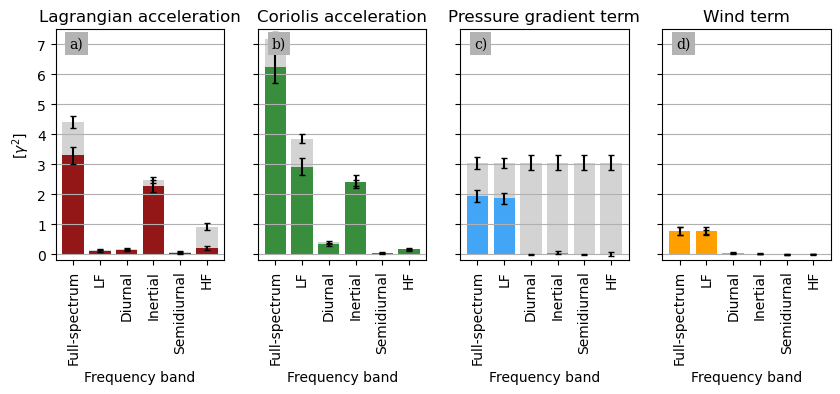

In [9]:
vars = ["acc", "cor", "ggd", "wd"]
title = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggd": "Pressure gradient term",
    "wd": "Wind term",
}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(1, 4, figsize=(10, 3), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
for j in range(len(vars)):
    ax = axs[j]
    df0["E_" + vars[j]].plot.bar(
        ax=ax,
        color="lightgrey",
        bottom=df0["B_" + vars[j]],
        yerr=df0["er__E_" + vars[j]],
        **kwargs
    )
    df0["B_" + vars[j]].plot.bar(
        ax=ax, color=c0[vars[j]], yerr=df0["er__B_" + vars[j]], **kwargs
    )
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_title(title[vars[j]])
    ax.set_ylim(-0.2, 7.5)

i = 0
for l in ["a", "b", "c", "d"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

## Frequency bandm

In [41]:
def cpd_to_hours(x):
    return 24 / x

In [50]:
cpd_to_hours(0.88), cpd_to_hours(1.05), cpd_to_hours(1.75), cpd_to_hours(
    1.9
), cpd_to_hours(2.1)

(27.272727272727273,
 22.857142857142858,
 13.714285714285714,
 12.631578947368421,
 11.428571428571429)